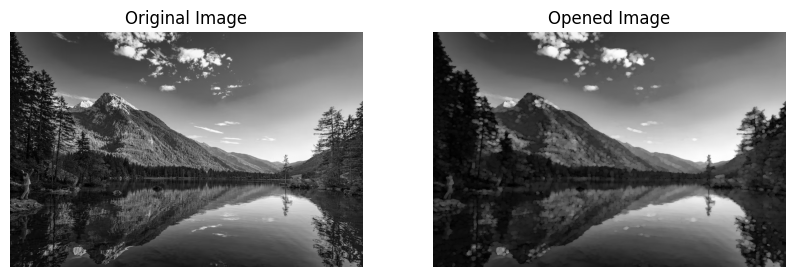

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the park image. Convert to grayscale as morphological operations are typically on single-channel images.
# If the image path is incorrect or the file doesn't exist, this will result in an error or a None image.
image_path = '/content/park image.avif' # Update this if your image is in a different location
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Check if image was loaded successfully
if image is None:
    raise FileNotFoundError(f"Error: Could not load image from {image_path}. Please check the path and file type.")

# Define a kernel (structuring element)
# A 5x5 elliptical kernel is a common choice
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

# Perform the Opening operation
# Opening = Erosion followed by Dilation
# It removes small objects while preserving the shape and size of larger objects
opened_image = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)

# Display the original and opened images
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(opened_image, cmap='gray')
plt.title('Opened Image')
plt.axis('off')

plt.show()

### Explanation:

1.  **Import Libraries**: We import `cv2` for OpenCV functions, `numpy` for array manipulation, and `matplotlib.pyplot` for displaying images.
2.  **Create Dummy Image**: A simple binary image is created with a few white squares of different sizes on a black background. In a real application, you would load your image using `image = cv2.imread('your_image.png', 0)` (the `0` loads it in grayscale).
3.  **Define Kernel**: The `cv2.getStructuringElement()` function is used to create a structuring element (kernel). A `cv2.MORPH_ELLIPSE` kernel of size `(5, 5)` is chosen, which is a common shape.
4.  **Perform Opening**: The `cv2.morphologyEx()` function is the core of the operation. We pass:
    *   The `image`.
    *   `cv2.MORPH_OPEN` to specify the opening operation.
    *   The `kernel` we defined.

    The opening operation first erodes the image (removing small objects and shrinking larger ones) and then dilates it (restoring the size of the remaining objects). The key effect is that very small objects or noise that was completely removed by erosion will not reappear after dilation.
5.  **Display Results**: Both the original and the processed images are displayed using `matplotlib` to visually compare the effect of the opening operation.